# System Configuration

## Library Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameter Values

In [2]:
N = 50  # Dimension of x
M = 50  # Dimension of y
K = 100  # Number of iterations

gamma_w = 10  # Inverse variance of noise w
x_var = 1.0  # Variance of x

## Python Class for VAMP - SLM

In [3]:
class VAMP_SLM:

  def __init__(self, A, y, x_var, gamma_w, K):
    """
    Parameters:
    - A: Measurement matrix (MxN)
    - y: Noisy observation (Mx1)
    - x_var: Variance of x
    - gamma_w: Inverse variance of noise w
    - K: Number of iterations
    """
    self.A = A
    self.y = y
    self.x_var = x_var
    self.gamma_w = gamma_w
    self.K = K

    self.M, self.N = A.shape  # Dimensions
    self.U, self.s, self.Vh = np.linalg.svd(A, full_matrices=False)  # SVD

    # Initial algorithm parameters
    self.r1 = np.zeros(self.N)  # Pseudo-measurement of x
    self.gamma1 = 0.1  # Inverse variance of Pseudo-measurement noise


  def g1_denoiser(self, r, gamma):
    """
    Denoiser (customized based on prior knowledge of x)
    """
    xhat = r * self.x_var / (self.x_var + (1 / gamma))
    alpha = self.x_var / (self.x_var + (1 / gamma))
    return xhat, alpha


  def g2_LMMSE(self, r, gamma):
    """
    LMMSE estimator
    """
    D = np.diag(1 / (self.gamma_w * self.s**2 + gamma))
    y_tilde = self.gamma_w * np.diag(self.s).T @ self.U.T @ self.y
    x_hat = self.Vh.T @ (D @ (y_tilde + gamma * (self.Vh @ r)))
    alpha = np.mean(gamma / (self.gamma_w * self.s**2 + gamma))
    return x_hat, alpha


  def run(self):
    """
    VAMP-SLM.
    """
    for k in range(self.K):
        # Denoising
        x1, alpha1 = self.g1_denoiser(self.r1, self.gamma1)
        r2 = (x1 - alpha1 * self.r1) / (1 - alpha1)
        gamma2 = self.gamma1 * (1 - alpha1) / alpha1

        # LMMSE estimation
        x2, alpha2 = self.g2_LMMSE(r2, gamma2)
        self.r1 = (x2 - alpha2 * r2) / (1 - alpha2)
        self.gamma1 = gamma2 * (1 - alpha2) / alpha2
    return x1

## Python Class for VAMP - GLM

In [4]:
class VAMP_GLM:

  def __init__(self, A, y, x_var, gamma_w, K):
    """
    Parameters:
    - A: Measurement matrix (MxN)
    - y: Noisy observation (Mx1)
    - x_var: Variance of x
    - gamma_w: Inverse variance of noise w
    - K: Number of iterations
    """
    self.A = A
    self.y = y
    self.x_var = x_var
    self.gamma_w = gamma_w
    self.K = K

    self.M, self.N = A.shape  # Dimensions
    self.U, self.s, self.Vh = np.linalg.svd(A, full_matrices=False)  # SVD

    # Initial algorithm parameters
    self.r1 = np.zeros(self.N)  # Pseudo-measurement of x
    self.p1 = np.zeros(self.M)  # Pseudo-measurement of z
    self.gamma1 = 0.1  # Inverse variance of Pseudo-measurement x noise
    self.tau1 = 0.1  # Inverse variance of Pseudo-measurement z noise


  def gx1_denoiser(self, r, gamma):
    """
    Denoiser for x
    """
    xhat = r * self.x_var / (self.x_var + (1 / gamma))
    alpha = self.x_var / (self.x_var + (1 / gamma))
    return xhat, alpha


  def gz1_denoiser(self, p, tau):
    """
    Denoiser for z
    """
    # Has to be implemented
    # z_hat = p * self.x_var / (self.x_var + (1 / tau))
    # beta = self.x_var / (self.x_var + (1 / tau))
    # return z_hat, beta


  def gx2_LMMSE(self, r2, p2, gamma2, tau2):
    """
    LMMSE estimator for x
    """
    D = np.diag(1 / (tau2 * self.s**2 + gamma2))
    x_hat = self.Vh.T @ (D @ (tau2 * np.diag(self.s).T @ self.U.T @ p2 + gamma2 * self.Vh @ r2))
    alpha = np.mean(gamma2 / (tau2 * self.s**2 + gamma2))
    return x_hat, alpha


  def gz2_LMMSE(self, r2, p2, gamma2, tau2):
    """
    LMMSE estimator for z
    """
    x_hat, alpha = self.gx2_LMMSE(r2, p2, gamma2, tau2)
    z_hat = self.A @ x_hat
    beta = (self.M / self.N) * (1 - alpha)
    return z_hat, beta


  def run(self):
    """
    VAMP-GLM
    """
    for k in range(self.K):
      # Denoising for x
      x1, alpha1 = self.gx1_denoiser(self.r1, self.gamma1)
      r2 = (x1 - alpha1 * self.r1) / (1 - alpha1)
      gamma2 = self.gamma1 * (1 - alpha1) / alpha1

      # Denoising for z
      z1, beta1 = self.gz1_denoiser(self.p1, self.tau1)
      p2 = (z1 - beta1 * self.p1) / (1 - beta1)
      tau2 = self.tau1 * (1 - beta1) / beta1

      # LMMSE estimation for x
      x2, alpha2 = self.gx2_LMMSE(r2, p2, gamma2, tau2)
      self.r1 = (x2 - alpha2 * r2) / (1 - alpha2)
      self.gamma1 = gamma2 * (1 - alpha2) / alpha2

      # LMMSE estimation for z
      z2, beta2 = self.gz2_LMMSE(r2, p2, gamma2, tau2)
      self.p1 = (z2 - beta2 * p2) / (1 - beta2)
      self.tau1 = tau2 * (1 - beta2) / beta2
    return x1

# VAMP - SLM

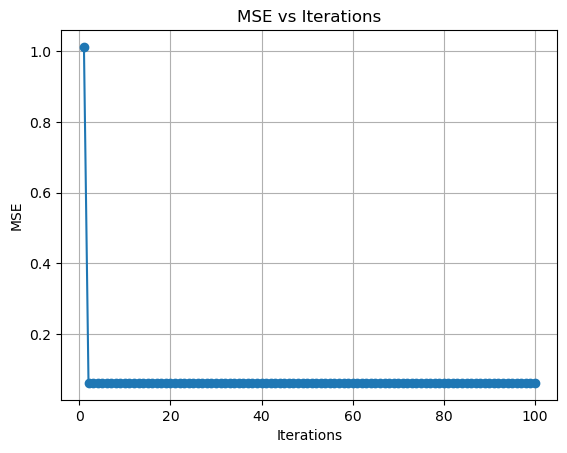

In [5]:
# True signal x
x_true = np.random.normal(0, np.sqrt(x_var), N)

# Measurement matrix A
A = np.random.randn(M, N)

# Noisy observation y
w = np.random.normal(0, np.sqrt(1 / gamma_w), M)
y = A @ x_true + w

mse_list = []
# VAMP-SLM estimate
for k in range(1,K+1):
  x1 = VAMP_SLM(A, y, x_var, gamma_w, k).run()

  # Mean Squared Error between the estimated and true x
  mse = np.mean((x1 - x_true) ** 2)
  mse_list.append(mse)

plt.plot(range(1,K+1), mse_list, marker='o')
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.title("MSE vs Iterations")
plt.grid()
plt.show()

# print("Mean Squared Error (MSE):", mse)
# print("Normalized Mean Squared Error (NMSE):", (mse / np.mean((x_true) ** 2)))
# print("True Norm of x:", np.linalg.norm(x_true))
# print("Estimated Norm of x:", np.linalg.norm(x1))

In [6]:
x1 = VAMP_SLM(A, y, x_var, gamma_w, K).run()
mse = np.mean((x1 - x_true) ** 2)

print("Mean Squared Error (MSE):", mse)
print("Normalized Mean Squared Error (NMSE):", (mse / np.mean((x_true) ** 2)))
print("True Norm of x:", np.linalg.norm(x_true))
print("Estimated Norm of x:", np.linalg.norm(x1))

Mean Squared Error (MSE): 0.06236080738814194
Normalized Mean Squared Error (NMSE): 0.06163155620345217
True Norm of x: 7.112778753014777
Estimated Norm of x: 6.964641186253381


# VAMP - GLM